# Resume Analyzer for Machine Learning / Data Science

## 1. Setup and Imports

In [5]:
# Install required libraries if you haven't already
# !pip install PyPDF2 nltk spacy scikit-learn matplotlib seaborn
# !python -m spacy download en_core_web_sm

import re
import string
import PyPDF2
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# NLTK setup
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

# Load spaCy NLP model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model en_core_web_sm...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to C:\Users\VIVOBBOK
[nltk_data]     16\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\VIVOBBOK
[nltk_data]     16\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


All libraries imported successfully!


## 2. Text Extraction

In [6]:
def extract_text_from_pdf(file_path):
    """Extracts text from a PDF file."""
    text = ""
    try:
        with open(file_path, "rb") as file:
            pdf_reader = PyPDF2.PdfReader(file)
            for page in pdf_reader.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    return text

resume_path = "Open-position-1.pdf"
resume_text = extract_text_from_pdf(resume_path)

print(f"Extracted {len(resume_text)} characters from the resume.")

Extracted 2593 characters from the resume.


## 3. NLP Preprocessing

In [7]:
def preprocess_text(text):
    """Cleans and preprocesses the text."""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    cleaned_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

cleaned_resume = preprocess_text(resume_text)
print("Preview of cleaned resume:\n", cleaned_resume[:200], "...")

Preview of cleaned resume:
 jr data scientist consorzio milano ricerche cmr – wwwmilanoricercheit hiring gradu ate students 1 one year contract junior data scientist positions cmr profit organisation working cooperative projects ...


## 4. Information Extraction (NER)

In [8]:
def extract_entities(text):
    """Extracts entities like email, phone numbers, and names."""
    entities = {}
    
    # 1. Email Extraction using Regex
    email_pattern = r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+'
    emails = re.findall(email_pattern, text)
    entities['Emails'] = list(set(emails))
    
    # 2. Phone Number Extraction using Regex (basic pattern)
    phone_pattern = r'\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b'
    phones = re.findall(phone_pattern, text)
    entities['Phones'] = list(set(phones))
    
    # 3. Name Extraction using spaCy NER
    doc = nlp(text)
    names = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    entities['Probable Name'] = names[0] if names else "Not Found"
    
    return entities

extracted_info = extract_entities(resume_text)
print("Extracted Entities:")
for key, val in extracted_info.items():
    print(f"{key}: {val}")

Extracted Entities:
Emails: ['recruitment@milanoricerche.it']
Phones: []
Probable Name: Twitter


## 5. Scoring & Job Matching

In [9]:
# Sample Job Description for a Data Scientist/ML Engineer
job_description = """
We are looking for a Data Scientist or Machine Learning Engineer with strong experience in Python.
You should be familiar with machine learning frameworks like TensorFlow, Keras, or PyTorch.
Experience with data analysis, data visualization, Pandas, NumPy, and SQL is required.
Knowledge of Natural Language Processing (NLP) and Deep Learning is a strong plus.
"""

cleaned_jd = preprocess_text(job_description)

# Required skills keyword list
required_skills = ["python", "data analysis", "machine learning", "deep learning", "ai", "nlp", "keras", "data visualization", "data science", "sql", "r", "pandas", "numpy", "pytorch", "tensorflow"]

def calculate_similarity(resume, jd):
    """Calculates cosine similarity between resume and job description."""
    vectorizer = TfidfVectorizer()
    # In case resume is empty, handle the exception
    if not resume.strip():
        return 0.0
    tfidf_matrix = vectorizer.fit_transform([resume, jd])
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    return similarity

def match_skills(resume_text, skills_list):
    """Finds which skills are present in the resume."""
    found_skills = []
    missing_skills = []
    resume_lower = resume_text.lower()
    
    for skill in skills_list:
        # Use regex to find whole words matching the skill
        if re.search(r'\b' + re.escape(skill) + r'\b', resume_lower):
            found_skills.append(skill)
        else:
            missing_skills.append(skill)
            
    return found_skills, missing_skills

similarity_score = calculate_similarity(cleaned_resume, cleaned_jd)
found_skills, missing_skills = match_skills(resume_text, required_skills)

print(f"Cosine Similarity Score (Resume vs JD): {similarity_score * 100:.2f}%")
print(f"Skills Found ({len(found_skills)}): {found_skills}")
print(f"Skills Missing ({len(missing_skills)}): {missing_skills}")

Cosine Similarity Score (Resume vs JD): 13.93%
Skills Found (1): ['data analysis']
Skills Missing (14): ['python', 'machine learning', 'deep learning', 'ai', 'nlp', 'keras', 'data visualization', 'data science', 'sql', 'r', 'pandas', 'numpy', 'pytorch', 'tensorflow']


## 6. Visualization & Reporting

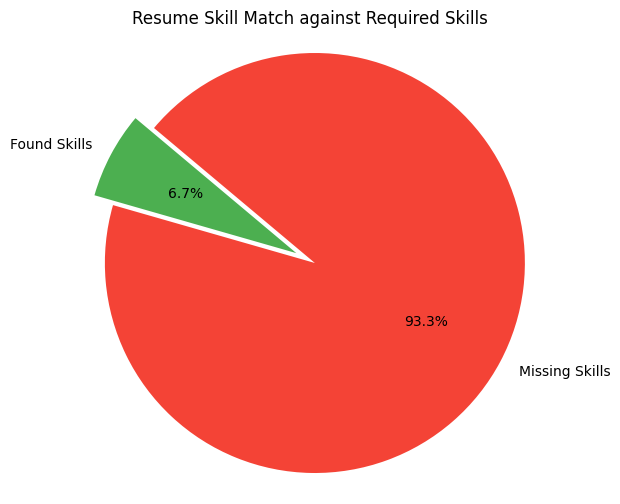

C:\Users\VIVOBBOK 16\AppData\Local\Temp\ipykernel_25284\4225081804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[score * 100], y=['Match'], orient='h', palette=['royalblue'])


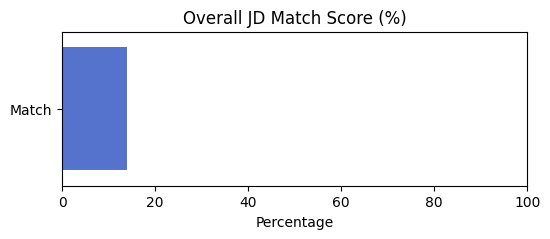

In [10]:
def visualize_skills(found, missing):
    """Visualizes the found vs missing skills."""
    labels = ['Found Skills', 'Missing Skills']
    sizes = [len(found), len(missing)]
    
    # If no skills required or found/missing are 0, skip pie chart
    if sum(sizes) == 0:
        print("No skills to visualize.")
        return
        
    colors = ['#4CAF50', '#F44336']
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, explode=(0.1, 0))
    plt.title("Resume Skill Match against Required Skills")
    plt.axis('equal')
    plt.show()

def visualize_similarity(score):
    """Visualizes the similarity score as a bar gauge."""
    plt.figure(figsize=(6, 2))
    sns.barplot(x=[score * 100], y=['Match'], orient='h', palette=['royalblue'])
    plt.xlim(0, 100)
    plt.title("Overall JD Match Score (%)")
    plt.xlabel("Percentage")
    plt.show()

visualize_skills(found_skills, missing_skills)
visualize_similarity(similarity_score)